## Pitch Rate Control System

In [1]:
import sys
sys.path.append('../')
from modeling.params_f16 import F16Params, Controls
from tools.lin_f16 import get_lin_f16 as linearize
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import tools.control_tools as tools

In [2]:
ALPHA_IDX = 1   # body-axis angle of attack
Q_IDX = 3   # body-axis pitch rate

ELEVATOR_IDX = 1 # elevator control input

RTOD = 57.2958  # radians to degrees
DTOR = 0.0174533  # degrees to radians

In [3]:
params = F16Params()
params.alt_ft = 0.0
params.VT_ftps = 502.0
params.xcg = 0.35
controls = Controls()

In [4]:
lon_sys, _ = linearize(controls, params)

Trim results:
Throttle (0-1): 0.26
Elevator (deg): -0.76
Alpha (deg): 2.12
Aileron (deg): 0.00
Rudder (deg): -0.00
Beta (deg): -0.00


In [5]:
ap = lon_sys.A[[ALPHA_IDX, Q_IDX]][:, [ALPHA_IDX, Q_IDX]]
bp = lon_sys.B[[ALPHA_IDX, Q_IDX]][:,[ELEVATOR_IDX]]
cp = lon_sys.C[[ALPHA_IDX, Q_IDX]][:, [ALPHA_IDX, Q_IDX]] * DTOR
dp = lon_sys.D[[ALPHA_IDX, Q_IDX]] [:,[ELEVATOR_IDX]]
plant = ct.ss(ap, bp, cp, dp)
plant

<LinearIOSystem:sys[4]:['u[0]']->['y[0]', 'y[1]']>

In [6]:
sysf = ct.ss(-10,10,1,0)
sysa = ct.ss(-20.2,20.2,1,0)
sys1 = ct.series(sysa,plant[0,0])
sys2 = ct.series(sys1,sysf)

In [7]:
DE_IDX = 0
ALPHA_IDX = 1
Q_IDX = 2
AF_IDX = 3
EPS_IDX = 4
a = sys2.A
eps_row = np.zeros([1,EPS_IDX+1])
eps_row[0,Q_IDX] = -57.3
a = np.append(a,np.zeros([np.shape(a)[0],1]),axis=1)
a = np.append(a,eps_row,axis=0)
b = sys2.B
b = np.append(b,np.zeros([1,1]),axis=0)
c = np.zeros([3,np.shape(a)[1]])
c[0,AF_IDX] = 57.3
c[1,Q_IDX] = 57.3
c[2,EPS_IDX] = 1
d = np.zeros([np.shape(c)[0],np.shape(b)[1]])
sys3 = ct.ss(a,b,c,d)
sys3

<LinearIOSystem:sys[12]:['u[0]']->['y[0]', 'y[1]', 'y[2]']>

#### Note:
#### $$ \dot{x} = Ax + Bu + Gr$$
#### $$ y = Cx + Fr $$
#### $$ z = Hx $$

In [8]:
A = sys3.A
B = sys3.B
C = sys3.C

g = np.zeros(np.shape(B))
g[EPS_IDX,0] = 1
f = np.zeros([np.shape(C)[0],1])
h = np.zeros([1,np.shape(A)[1]])
h[0,Q_IDX] = 57.3

print('G =\n', g)

print('F =\n', f)

print('H = \n', h)

G =
 [[0.]
 [0.]
 [0.]
 [0.]
 [1.]]
F =
 [[0.]
 [0.]
 [0.]]
H = 
 [[ 0.   0.  57.3  0.   0. ]]


#### Check Stability of Initial Guess

In [9]:
K_0= np.array([[0, -2, 1]])
A_c = sys3.A - sys3.B @ K_0 @ sys3.C
D = np.linalg.eig(A_c)
D.eigenvalues < 0

array([ True,  True,  True,  True,  True])

In [10]:
P_base = abs(h.T @ h)
print('P =\n', P_base)

Q = np.array([[0]])
print('Q =\n', Q)

R = np.array([[10]])  # control effort weight
print('R =\n', R)

P =
 [[   0.      0.      0.      0.      0.  ]
 [   0.      0.      0.      0.      0.  ]
 [   0.      0.   3283.29    0.      0.  ]
 [   0.      0.      0.      0.      0.  ]
 [   0.      0.      0.      0.      0.  ]]
Q =
 [[0]]
R =
 [[10]]


In [11]:
K_opt = tools.LQTrackerTime(sys3,g,f,P_base,Q,R,K_0)

J_opt = 0.13401736250323973
K_opt =
 [[ 0.02263158 -1.69800299  4.01112586]]


In [12]:
# K_opt = np.array([[-0.05, -1, 4]])
A_c = sys3.A - sys3.B @ K_opt @ sys3.C
eigenvalues = np.linalg.eigvals(A_c)
print('Closed-loop eigenvalues:\n', eigenvalues)

Closed-loop eigenvalues:
 [ -9.37812057+15.19328445j  -9.37812057-15.19328445j
 -10.02345727 +0.j          -2.44175908 +0.j
  -1.07417753 +0.j        ]


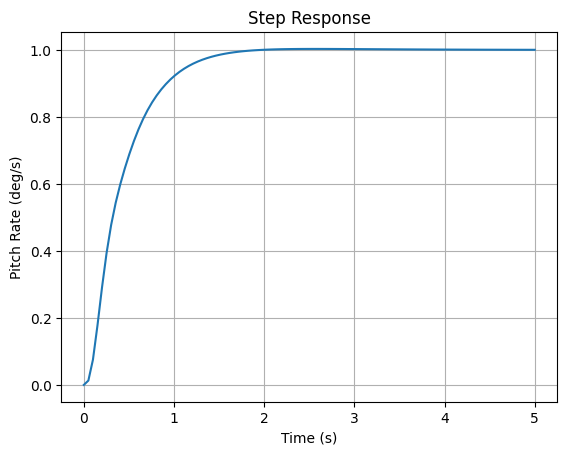

In [13]:
syscl = ct.ss(sys3.A - sys3.B @ K_opt @ sys3.C, g - sys3.B @ K_opt @ f, sys3.C[1], np.array([[0]]))
t = np.linspace(0, 5, 100)
plt.figure()
tools.plot_step(syscl, t, 'Pitch Rate (deg/s)', 'Step Response')

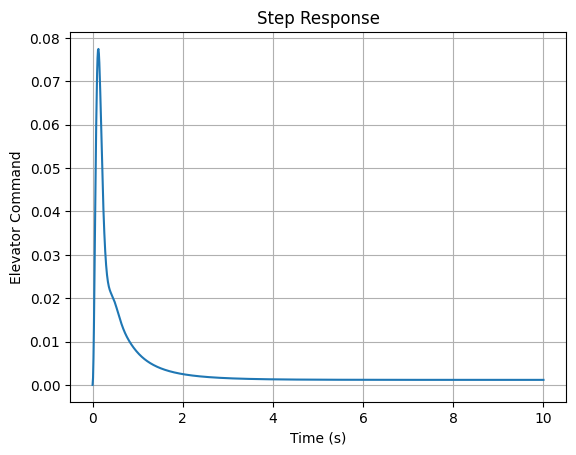

In [14]:
K = K_opt
A_c = sys3.A - sys3.B @ K @ sys3.C
syscl = ct.ss(A_c, g - sys3.B @ K @ f, np.eye(len(sys3.A)), np.zeros([len(sys3.A),1]))

t = np.linspace(0,10,1000)
def cost_eqn(t,e,u,R,dt):
    return ( 0.5 * t**2 * e**2 + R * u**2 ) * dt

t, y = ct.step_response(syscl, t)

u = np.zeros([sys3.B.shape[0],sys3.B.shape[1],len(t)])
for i in range(len(t)):
    u[:,:,i] = -K @ sys3.C @ y[:,:,i]

plt.plot(t, u[0,0,:]**2)
plt.xlabel('Time (s)')
plt.ylabel('Elevator Command')
plt.title('Step Response')
plt.grid()
plt.show()

#### Inspect K from text

In [15]:
K = np.array([[-0.046, -1.072, 3.381]])
def perf_index(sys, r, Q, R, K):
    Q_eff = sys.C.T @ K.T @ R @ K @ sys.C + Q

    A_c = sys.A - sys.B @ K @ sys.C
    B_c = g - sys.B @ K @ f
    # Solve Lyapunov equation for P
    P = tools.lyapunov(A_c,P_base)
    P = tools.lyapunov(A_c,2*P + Q_eff)
    X = np.linalg.inv(A_c) @ B_c @ r @ r.T @ B_c.T @ np.linalg.inv(A_c).T
    J = 0.5 * np.trace(P @ X)

    return J

J_k = perf_index(sys3,np.array([[1]]),Q,R,K_0)
print(f"J = {J_k}")

J = 1.0525376495409615


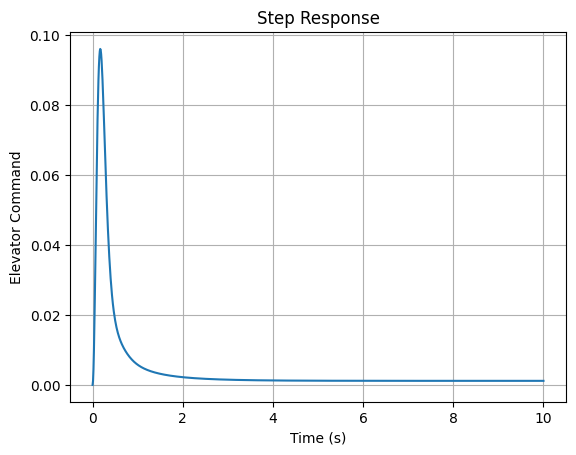

In [16]:
A_c = sys3.A - sys3.B @ K @ sys3.C
syscl = ct.ss(A_c, g - sys3.B @ K @ f, np.eye(len(sys3.A)), np.zeros([len(sys3.A),1]))

t = np.linspace(0,10,1000)
def cost_eqn(t,e,u,R,dt):
    return ( 0.5 * t**2 * e**2 + R * u**2 ) * dt

t, y = ct.step_response(syscl, t)

u = np.zeros([sys3.B.shape[0],sys3.B.shape[1],len(t)])
for i in range(len(t)):
    u[:,:,i] = -K @ sys3.C @ y[:,:,i]

plt.plot(t, u[0,0,:]**2)
plt.xlabel('Time (s)')
plt.ylabel('Elevator Command')
plt.title('Step Response')
plt.grid()
plt.show()